In [15]:
import pandas as pd
df = pd.read_csv("../data/Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [17]:
df.shape

(200, 5)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [20]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [21]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

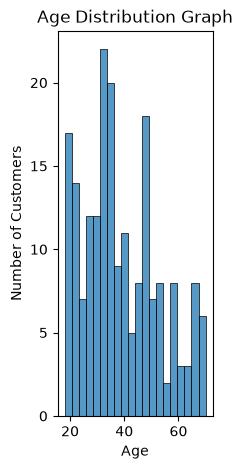

In [30]:
import matplotlib.pyplot as pt
import seaborn as sns
plt.figure(figsize=(2,5))
sns.histplot(df["Age"],bins=20)
plt.title("Age Distribution Graph")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

AnnualIncomeDisrtibution

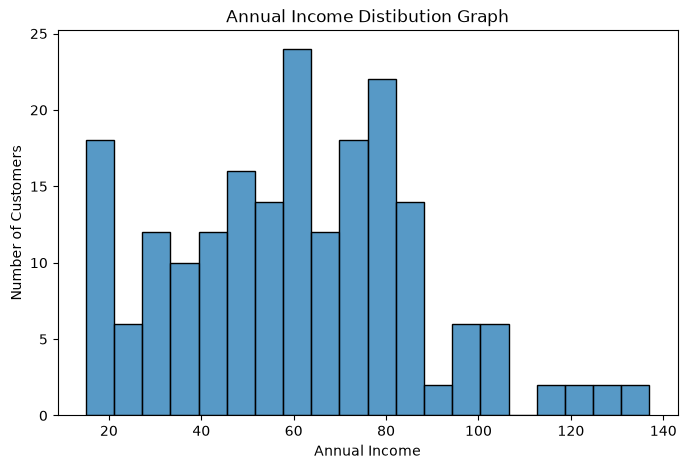

In [33]:
import matplotlib.pyplot as pt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df["Annual Income (k$)"],bins=20)
plt.title("Annual Income Distibution Graph")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")
plt.show()

Score Distribution

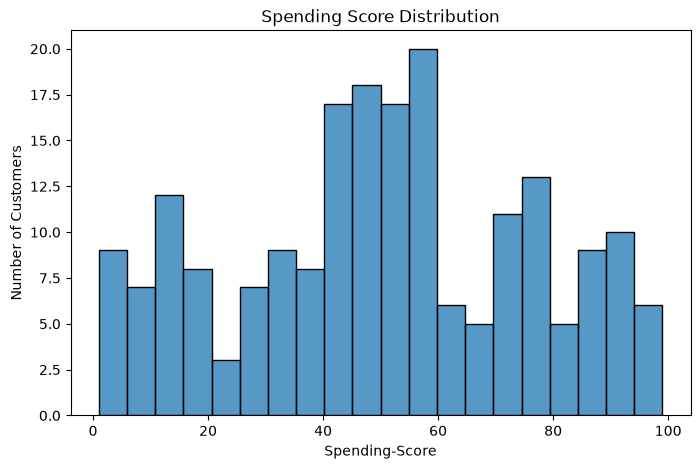

In [36]:
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize=(8,5))
sns.histplot(df["Spending Score (1-100)"],bins=20)
plt.title("Spending Score Distribution")
plt.xlabel("Spending-Score")
plt.ylabel("Number of Customers")
plt.show()


Customers Segmentation Using K-Means

In [38]:
X = df[["Annual Income (k$)","Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5] 

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

Calcualte WCSS

In [49]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state = 42,
        n_init = 10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


Draw the Elbow Graph

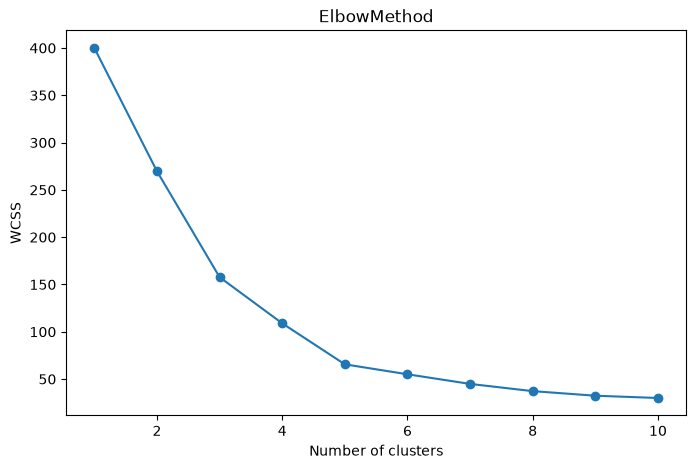

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker="o")
plt.title("ElbowMethod")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [53]:
kmeans = KMeans(
    n_clusters = 5,
    random_state = 42,
    n_init = 10

)
df["clusters"] = kmeans.fit_predict(X_scaled)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


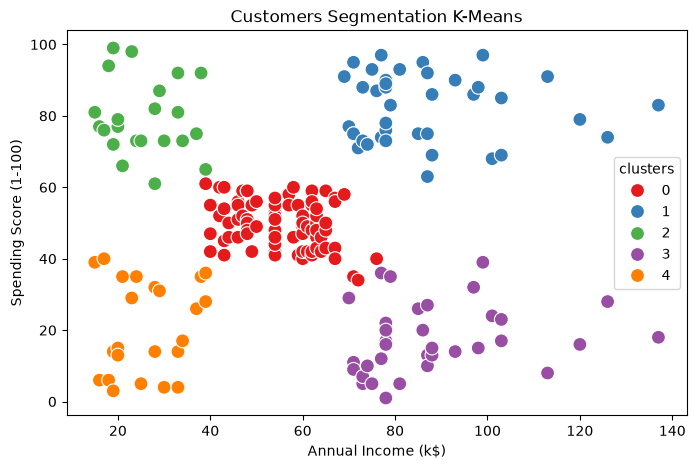

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Annual Income (k$)",
    y= "Spending Score (1-100)",
    hue = "clusters",
    data = df,
    palette = "Set1",
    s=100
)
plt.title("Customers Segmentation K-Means")
plt.show()

In [62]:
df.groupby("clusters")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
clusters,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [63]:
df.to_csv("customer_segments.csv", index=False)